In [22]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['Hp'] = '#63D15Aff'
    genotype_color['ArchT'] = '#FF9BD6ff'
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['WT'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
'#C276A5'

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [24]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

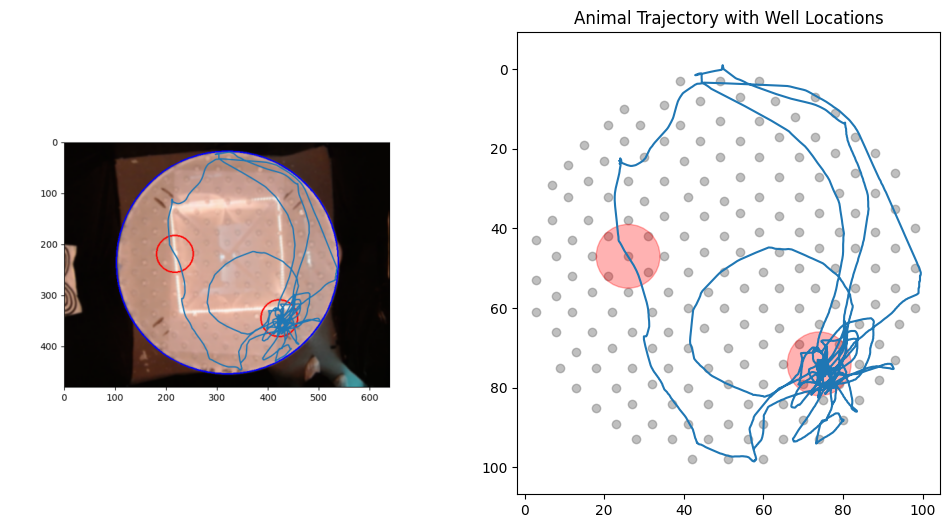

In [25]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [26]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [27]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


In [28]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,63,BR,20251223,8,5,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5142,63,BR,20251223,8,6,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5143,63,BR,20251223,8,7,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN
5144,63,BR,20251223,8,8,L,5,NaN,1,NaN,F231A,NaN,0,0,0,NaN


In [29]:
# Compute pct time in trigger zone
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
  
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    total_time_in_trigger = df_all_triggers['duration'].sum()

    # Trial duration: max time in this trial (same units as duration)
    trial_duration = position_['t'].max()

    if trial_duration > 0:
        pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    else:
        pct_time_in_trigger = np.nan

    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger


 15%|█▌        | 709/4609 [00:07<00:41, 93.34it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1178/4609 [00:13<00:35, 95.83it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 56%|█████▋    | 2604/4609 [00:27<00:14, 139.74it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:45<00:00, 101.09it/s]


  3%|▎         | 121/4609 [00:01<00:39, 114.89it/s]

C, ses-05_date-20241004 likely triggerLoc missing


  8%|▊         | 357/4609 [00:03<00:40, 104.72it/s]

AD, ses-01_date-20250530 likely triggerLoc missing
AD, ses-03_date-20250601 likely triggerLoc missing
AD, ses-04_date-20250602 likely triggerLoc missing


  9%|▉         | 417/4609 [00:03<00:37, 112.11it/s]

...

BP, ses-08_date-20251223 likely triggerLoc missing
BP, ses-08_date-20251223 likely triggerLoc missing


 98%|█████████▊| 4535/4609 [00:35<00:00, 126.62it/s]

BQ, ses-04_date-20251219 likely triggerLoc missing
BQ, ses-05_date-20251220 likely triggerLoc missing
BQ, ses-06_date-20251221 likely triggerLoc missing
BQ, ses-06_date-20251221 likely triggerLoc missing
BQ, ses-07_date-20251222 likely triggerLoc missing
BQ, ses-07_date-20251222 likely triggerLoc missing
BQ, ses-07_date-20251222 likely triggerLoc missing


100%|██████████| 4609/4609 [00:36<00:00, 127.45it/s]


BR, ses-08_date-20251223 likely triggerLoc missing
WT animals plotted: 4

WT learning days (L1–L5): mean across animals
-------------------------------------------------
Day 1: 32.50%  |  22094.50 s
Day 2: 40.98%  |  24254.03 s
Day 3: 33.10%  |  15305.19 s
Day 4: 37.62%  |  15769.69 s
Day 5: 41.68%  |  16951.12 s

WT overall average across L1–L5 (per-animal mean, then group mean):
-------------------------------------------------
37.18%  |  18874.91 s


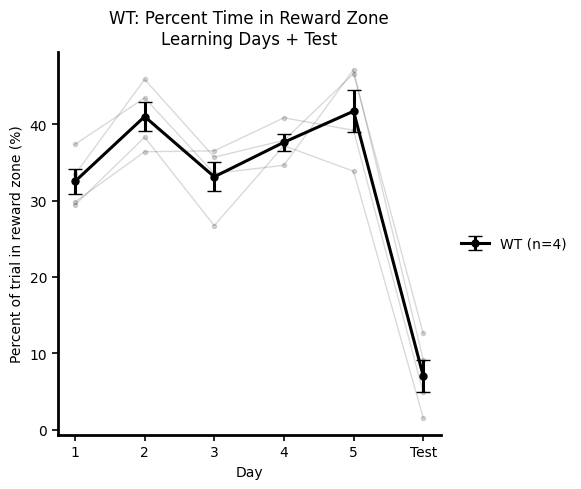

In [ ]:

# ============================================================
# WT: Print learning-day averages (% + seconds) + plot % across L1–L5 + Test
# Assumes you already have:
#   metadata['pct_time_in_trigger']   (percent)
#   metadata['time_in_trigger_s']     (seconds)
# ============================================================

# ------------------------------------------------------------
# 1) Filter: WT, usable, not short, L/T, metric present
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'WT') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['time_in_trigger_s'].notna())
].copy()

# Assign plot_day: L -> 1..5 ; T -> 6 (first T session after last L per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue
    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 2) Build subject × day matrices (require complete 1..6)
# ------------------------------------------------------------
def build_subject_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_pct, subs = build_subject_matrix(meta_LT, 'pct_time_in_trigger')
mat_s,   _    = build_subject_matrix(meta_LT, 'time_in_trigger_s')

print("WT animals plotted:", 0 if subs is None else len(subs))

# ------------------------------------------------------------
# 3) Print learning-day averages in % and seconds
#    - per day mean across animals
#    - overall across L1–L5 (per-animal mean, then group mean)
# ------------------------------------------------------------
if mat_pct is not None and mat_s is not None and len(subs) > 0:
    print("\nWT learning days (L1–L5): mean across animals")
    print("-------------------------------------------------")
    for d in [1, 2, 3, 4, 5]:
        j = d - 1
        mean_pct  = np.nanmean(mat_pct[:, j])
        mean_time = np.nanmean(mat_s[:, j])
        print(f"Day {d}: {mean_pct:.2f}%  |  {mean_time:.2f} s")

    per_animal_pct_5  = np.nanmean(mat_pct[:, 0:5], axis=1)
    per_animal_time_5 = np.nanmean(mat_s[:, 0:5], axis=1)

    overall_pct  = np.nanmean(per_animal_pct_5)
    overall_time = np.nanmean(per_animal_time_5)

    print("\nWT overall average across L1–L5 (per-animal mean → group mean):")
    print("-------------------------------------------------")
    print(f"{overall_pct:.2f}%  |  {overall_time:.2f} s")
else:
    print("\nNo WT animals with complete days 1–6 for these metrics.")

# ------------------------------------------------------------
# 4) Plot: % time in trigger (individual + mean ± SEM)
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5

if mat_pct is not None and len(subs) > 0:
    # color (fallback to black if WT not in your color map)
    try:
        col = get_genotype_color('WT')
    except Exception:
        col = 'k'

    # individuals
    for row in mat_pct:
        plt.plot(
            x_vals, row,
            '-o',
            color=col,
            alpha=0.15,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # mean ± SEM
    mean_ = np.nanmean(mat_pct, axis=0)
    sem_  = np.nanstd(mat_pct, axis=0) / np.sqrt(mat_pct.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=col,
        capsize=5,
        linewidth=2.2,
        markersize=5,
        label=f'WT (n={len(subs)})'
    )

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('WT: Percent Time in Reward Zone\nLearning Days + Test')

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# WT: Print learning-day averages (% + seconds) + plot % across L1–L5 + Test
# Uses:
#   - metadata['pct_time_in_trigger']  (already computed)
#   - trial duration from metadata if present, otherwise requires you to provide it
# ============================================================

# ------------------------------------------------------------
# 0) Choose how to get trial duration (ms)
# ------------------------------------------------------------
# If you already have a duration column in metadata, put it here.
# Common candidates (edit if yours differs):
DUR_COL_CANDIDATES = ['trial_duration_ms', 'trial_dur_ms', 'duration_ms', 'trial_duration', 't_max']

dur_col = next((c for c in DUR_COL_CANDIDATES if c in metadata.columns), None)
if dur_col is None:
    raise KeyError(
        "No trial duration column found in metadata. "
        "Add one (e.g. metadata['trial_duration_ms']) or edit DUR_COL_CANDIDATES to match your column name."
    )

# ------------------------------------------------------------
# 1) Filter: WT, usable, not short, L/T, pct present, duration present
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'WT') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata[dur_col].notna())
].copy()

# Make derived actual time in trigger (seconds)
# (assumes dur_col is in ms)
meta_LT['time_in_trigger_s'] = (meta_LT['pct_time_in_trigger'] / 100.0) * (meta_LT[dur_col].astype(float) / 1000.0)

# Assign plot_day: L -> 1..5 ; T -> 6 (first T session after last L per animal)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue
    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)

# ------------------------------------------------------------
# 2) Build subject × day matrices (require complete 1..6)
# ------------------------------------------------------------
def build_subject_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]
        mean_by_day = ms.groupby('plot_day')[value_col].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_pct, subs = build_subject_matrix(meta_LT, 'pct_time_in_trigger')
mat_s,   _    = build_subject_matrix(meta_LT, 'time_in_trigger_s')

print("WT animals plotted:", 0 if subs is None else len(subs))

# ------------------------------------------------------------
# 3) Print learning-day averages in % and seconds
# ------------------------------------------------------------
if mat_pct is not None and mat_s is not None and len(subs) > 0:
    print("\nWT learning days (L1–L5): mean across animals")
    print("-------------------------------------------------")
    for d in [1, 2, 3, 4, 5]:
        j = d - 1
        mean_pct  = np.nanmean(mat_pct[:, j])
        mean_time = np.nanmean(mat_s[:, j])
        print(f"Day {d}: {mean_pct:.2f}%  |  {mean_time:.2f} s")

    per_animal_pct_5  = np.nanmean(mat_pct[:, 0:5], axis=1)
    per_animal_time_5 = np.nanmean(mat_s[:, 0:5], axis=1)

    overall_pct  = np.nanmean(per_animal_pct_5)
    overall_time = np.nanmean(per_animal_time_5)

    print("\nWT overall average across L1–L5 (per-animal mean → group mean):")
    print("-------------------------------------------------")
    print(f"{overall_pct:.2f}%  |  {overall_time:.2f} s")
else:
    print("\nNo WT animals with complete days 1–6 for these metrics.")

# ------------------------------------------------------------
# 4) Plot: % time in trigger (individual + mean ± SEM)
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5

if mat_pct is not None and len(subs) > 0:
    # WT color fallback
    try:
        col = get_genotype_color('WT')
    except Exception:
        col = 'k'

    # individuals
    for row in mat_pct:
        plt.plot(
            x_vals, row,
            '-o',
            color=col,
            alpha=0.15,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # mean ± SEM
    mean_ = np.nanmean(mat_pct, axis=0)
    sem_  = np.nanstd(mat_pct, axis=0) / np.sqrt(mat_pct.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=col,
        capsize=5,
        linewidth=2.2,
        markersize=5,
        label=f'WT (n={len(subs)})'
    )

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('WT: Percent Time in Reward Zone\nLearning Days + Test')

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

KeyError: "No trial duration column found in metadata. Add one (e.g. metadata['trial_duration_ms']) or edit DUR_COL_CANDIDATES to match your column name."

        group  animal  pct_time_in_trigger
0        ChR2       1            29.578657
1        ChR2       3            35.765130
2        ChR2       4            34.803665
3        ChR2       6            19.793126
4        ChR2       7            11.939570
5        ChR2       8            30.509764
6        ChR2       9            25.763918
7        ChR2      10            16.308726
8        ChR2      11            12.028290
9        ChR2      12            23.016142
10       ChR2      16             9.566117
11       ChR2      18            20.722655
12         Hp      40             5.255492
13         Hp      41             4.780728
14         Hp      42             1.849510
15         Hp      43             2.079009
16         Hp      44             2.451215
17         Hp      45             6.376267
18         Hp      46             6.236343
19  eYFP_ChR2      19             2.327057
20  eYFP_ChR2      20             2.105439
21  eYFP_ChR2      21             0.701039
22  eYFP_Ch

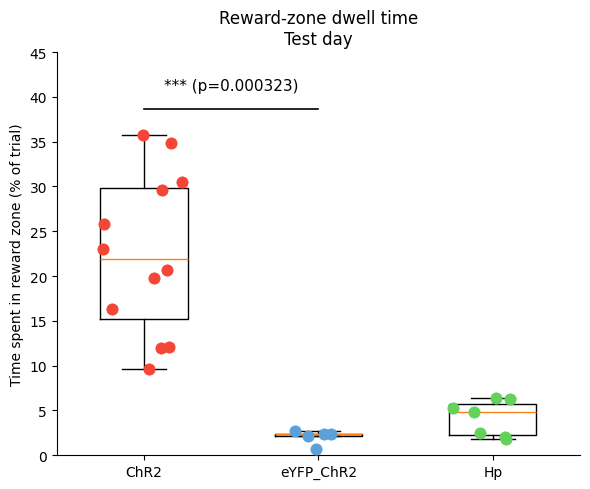

In [9]:
# test day plot + rank sum test

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
 #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

#groups = ['ChR2', 'eYFP_ChR2']
groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}


# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group','animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data
data = [meta_animal.loc[meta_animal['group']==g, 'pct_time_in_trigger'].values
        for g in groups]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # keep plain black box
    showfliers=False      # <-- turn off those empty circles
)


# individual animal points
for i, g in enumerate(groups):
    vals = meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    n = len(vals)

    # wider jitter for dense groups
    jitter = 0.12 if n < 6 else 0.12  # adjust if needed

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum test (Mann–Whitney U) + stars
# ------------------------------------------------------------
vals_ch = data[0]  # ChR2
vals_yf = data[1]  # eYFP_ChR2

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax = max(np.nanmax(vals_ch), np.nanmax(vals_yf))
# put the line a bit above the max data point
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between the two boxes (x=0 and x=1)
plt.plot([0, 0, 1, 1], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

# text with stars + p-value
plt.text(0.5, y_star, f"{stars} (p={p:.3g})",
         ha='center', va='bottom', fontsize=11)

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, 45)

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 0) Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T'])) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['sub'] != 17)
].copy()

plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1) Helper: build subject × day matrix (enforces L/SL days 1–5
#    + FIRST T session AFTER last learning session as day 6)
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) pct_time_in_trigger per day
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # subset by genotype and L/SL + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # assign learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # ----- KEY LINE: first T session AFTER last learning session -----
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2) Build matrices for the three groups
#    Group 1: ChR2 long (L, short_duration=0)
#    Group 2: eYFP_ChR2 (L, any short_duration)
#    Group 3: ChR2 short (SL, short_duration=1)
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted :", len(subs_ChR2_long))
print("ChR2 short animals plotted:", len(subs_ChR2_short))
print("eYFP_ChR2 animals plotted :", len(subs_eYFP))


# ------------------------------------------------------------
# 3) Extract TEST DAY (day 6) values for each animal
#     → matrices are (n_animals x 6), index 5 = test day
# ------------------------------------------------------------
vals_ChR2_long  = mat_ChR2_long[:, 5]   # Day 6
vals_ChR2_short = mat_ChR2_short[:, 5]
vals_eYFP       = mat_eYFP[:, 5]

groups = ['ChR2 long', 'ChR2 short', 'eYFP_ChR2']
data   = [vals_ChR2_long, vals_ChR2_short, vals_eYFP]

colors = {
    'ChR2 long'  : get_genotype_color('ChR2'),
    'ChR2 short' : get_genotype_color('ChR2_short'),
    'eYFP_ChR2'  : get_genotype_color('eYFP_ChR2')
}

# ------------------------------------------------------------
# 4) Plot boxplot + jittered animal points + animal labels
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,
    showfliers=False
)

for i, g in enumerate(groups):
    vals = data[i]
    subs = [subs_ChR2_long, subs_ChR2_short, subs_eYFP][i]   # matching subject lists
    n = len(vals)

    jitter = 0.12
    x = np.random.normal(i, jitter, size=n)

    # plot points
    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )


# ------------------------------------------------------------
# 5) Rank-sum (Mann–Whitney) for ChR2_long vs eYFP_ChR2
#    (line between box 0 and box 2; ChR2_short is box 1)
# ------------------------------------------------------------
vals_ch = vals_ChR2_short
vals_yf = vals_eYFP

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax  = np.nanmax(np.concatenate([vals_ChR2_long, vals_ChR2_short, vals_eYFP]))
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between x=0 (ChR2 long) and x=2 (eYFP_ChR2)
plt.plot([0, 0, 2, 2], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

plt.text(
    1.0, y_star,
    f"{stars} (p={p:.3g})",
    ha='center', va='bottom', fontsize=11
)


# ------------------------------------------------------------
# 6) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups, rotation=0)
plt.ylim(0, 55)

plt.ylabel('Time spent in reward zone (% of test trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day (after L/SL Days 1–5)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

ChR2 long animals plotted : 12
ChR2 short animals plotted: 0
eYFP_ChR2 animals plotted : 5


TypeError: 'NoneType' object is not subscriptable

        group  animal  pct_time_in_trigger
0        ChR2       1            29.578657
1        ChR2       3            35.765130
2        ChR2       4            34.803665
3        ChR2       6            19.793126
4        ChR2       7            11.939570
5        ChR2       8            30.509764
6        ChR2       9            25.763918
7        ChR2      10            16.308726
8        ChR2      11            12.028290
9        ChR2      12            23.016142
10       ChR2      16             9.566117
11       ChR2      18            20.722655
12         Hp      40             5.255492
13         Hp      41             4.780728
14         Hp      42             1.849510
15         Hp      43             2.079009
16         Hp      44             2.451215
17         Hp      45             6.376267
18         Hp      46             6.236343
19  eYFP_ChR2      19             2.327057
20  eYFP_ChR2      20             2.105439
21  eYFP_ChR2      21             0.701039
22  eYFP_Ch

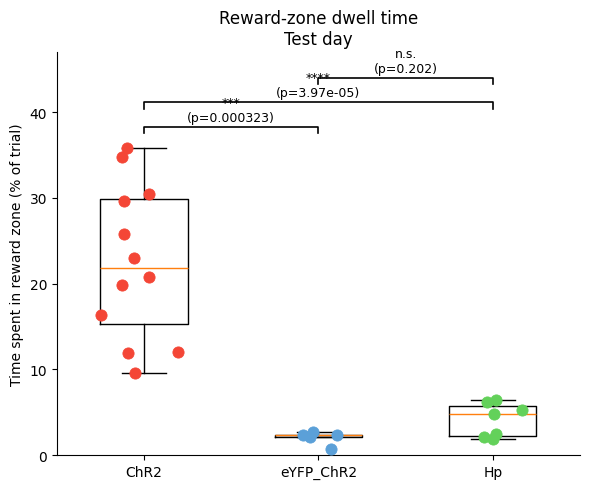

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only (now incl. Hp)
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}

# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group', 'animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data in group order
data = [
    meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    for g in groups
]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # plain black box
    showfliers=False      # no empty circles
)

# individual animal points
for i, g in enumerate(groups):
    vals = data[i]
    n = len(vals)

    if n == 0:
        continue

    jitter = 0.12 if n < 6 else 0.12

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum tests (Mann–Whitney U) + stars for all pairs
# ------------------------------------------------------------
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

# all pairs: (ChR2 vs eYFP), (ChR2 vs Hp), (eYFP vs Hp)
pairs = [(0, 1), (0, 2), (1, 2)]

# base height for annotations
all_vals = np.concatenate([d for d in data if len(d) > 0])
ymax = np.nanmax(all_vals)
y_step = ymax * 0.08
current_y = ymax * 1.05

for (i, j) in pairs:
    vals_i = data[i]
    vals_j = data[j]

    # skip if any group empty
    if len(vals_i) == 0 or len(vals_j) == 0:
        continue

    stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')
    print(f"{groups[i]} vs {groups[j]}: Mann–Whitney U p = {p:.3g}")

    stars = p_to_stars(p)

    x1, x2 = i, j
    x_mid = (x1 + x2) / 2.0

    # bracket line
    plt.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.02*ymax, current_y + 0.02*ymax, current_y],
        color='black',
        linewidth=1.2
    )

    # text (stars + p)
    plt.text(
        x_mid,
        current_y + 0.03*ymax,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # stack brackets upward

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, max(45, current_y + y_step * 0.3))

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean % time in trigger zone per training day
    mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
    mean_pct_by_day = mean_pct_by_day.sort_index()

    # Expect 5 days; skip incomplete animals
    if len(mean_pct_by_day) != 5:
        continue

    performance_mat.append(mean_pct_by_day.values)

    # Individual subject traces (thin black)
    plt.plot(range(5), mean_pct_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM
performance_mat = np.vstack(performance_mat)
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

plt.errorbar(
    range(5),
    mean_performance,
    yerr=sem_performance,
    fmt='-o',
    color='r',
    capsize=5
)

plt.xlabel('Learning Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


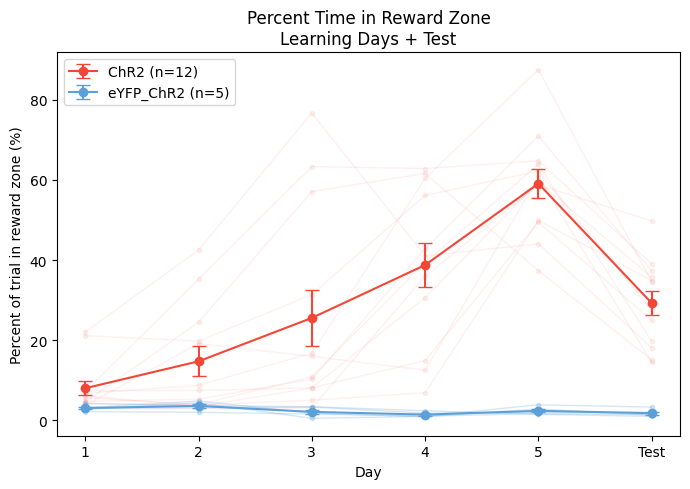

In [12]:
# plot ChR2 & eYFP_ChR2 learning trials + first test day (by session) after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2
if mat_ChR2 is not None:
    col_c = get_genotype_color('ChR2')

    # individual traces
    for row in mat_ChR2:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_c,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c, yerr=sem_c,
        fmt='-o',
        color=col_c,
        capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# eYFP_ChR2
if mat_eYFP is not None:
    col_y = get_genotype_color('eYFP_ChR2')

    # individual traces
    for row in mat_eYFP:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_y,
            alpha=0.25,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y, yerr=sem_y,
        fmt='-o',
        color=col_y,
        capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

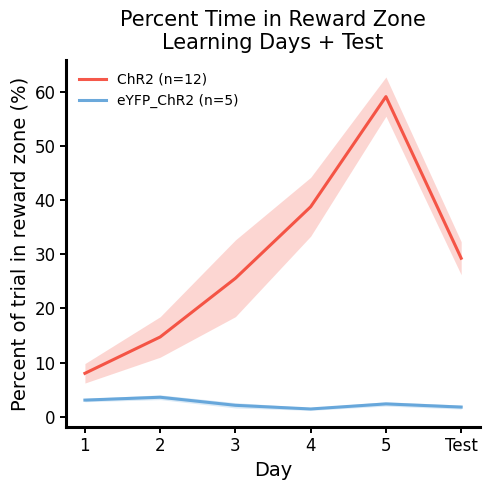

In [13]:
# ---------------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, journal-style
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) values of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individual traces)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot both groups using your color function ---
plot_group_shaded(
    mat_ChR2,
    subs_ChR2,
    genotype_key='ChR2',
    label='ChR2'
)

plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2'
)

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5


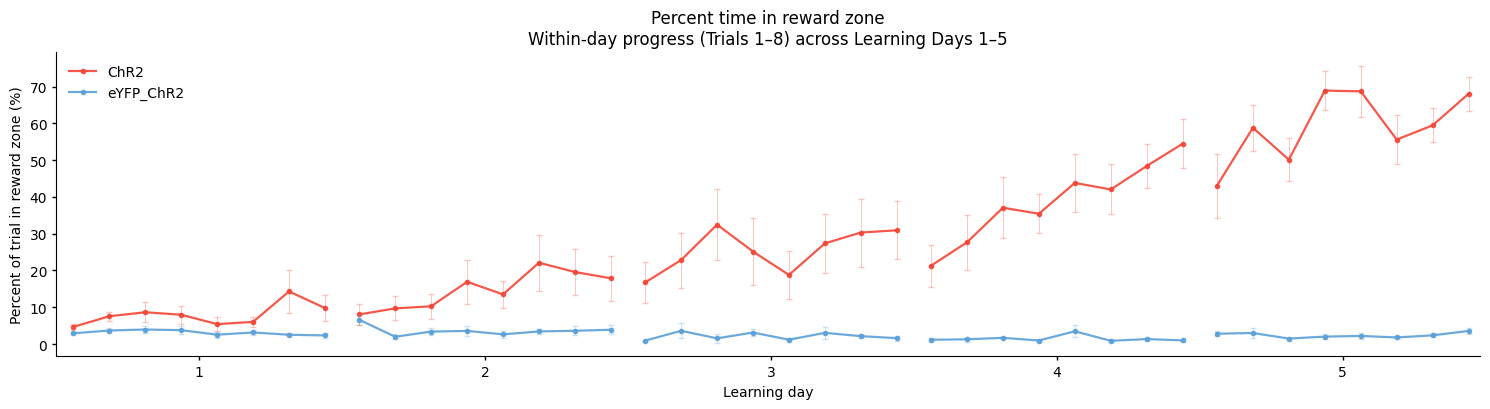

In [14]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_time_in_trigger (% of trial in reward zone)
# Groups: ChR2 vs eYFP_ChR2  (others available via comments)
# ============================================================

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &  ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    # (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_time_in_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials])
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves using color function
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key, label=None, alpha=1.0):
    """
    genotype_key: key for get_genotype_color, e.g.
                  'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp', ...
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # for showing legend label once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # ---- mean line ----
        ax.plot(
            x, mean_,
            'o-',
            color=col,
            alpha=alpha,
            linewidth=1.6,
            markersize=3,
            label=label if first_day and (label is not None) else None
        )

        # ---- SEM bars (faded) ----
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=col,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

        first_day = False

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (all options kept)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
# meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
# meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
# meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# if plotting for short duration:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()
#
# meta_eYFP_L = meta_L[
#     (meta_L['genotype'] == 'eYFP_ChR2') &
#     (meta_L['trial_type'] == 'L')
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())
# print("  ChR2 long:", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day labels under each day's curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha=0.9
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha=0.9
)

# other groups, ready to use when you want:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha=0.7
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha=0.9
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5


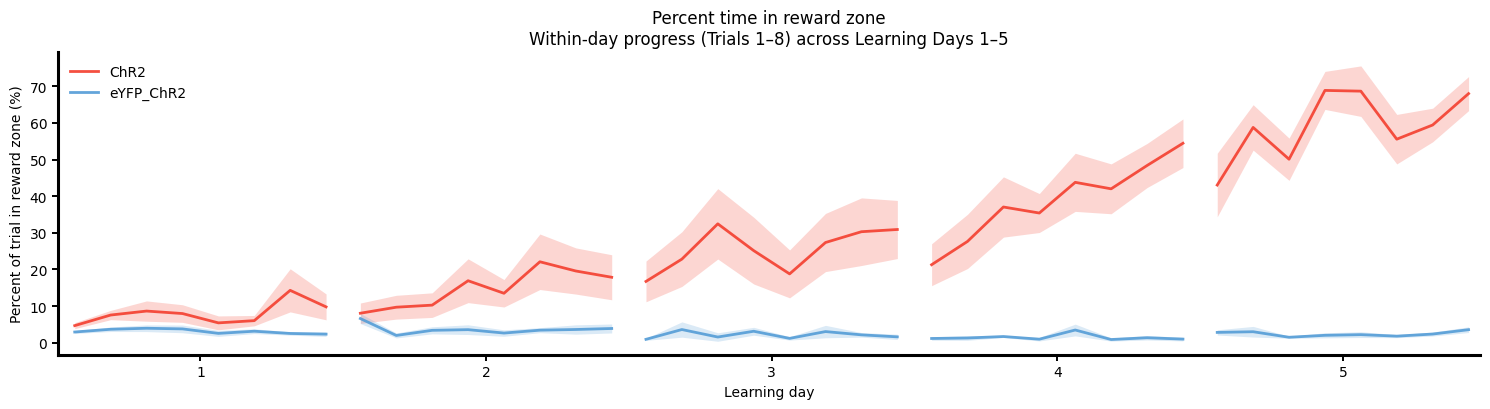

In [15]:
# ------------------------------------------------------------
# 4) Plot helper: within-day curves with shaded SEM
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key,
                           label=None,
                           alpha_fill=0.22,
                           alpha_line=0.9):
    """
    meta_g:   subset of metadata for a given group
    genotype_key: key for get_genotype_color, e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    label:    legend label (shown once per group)
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # to only add legend entry once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # shaded SEM band
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=alpha_fill,
            linewidth=0
        )

        # mean line (no markers)
        ax.plot(
            x, mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None
        )

        first_day = False


# ------------------------------------------------------------
# 5) Nature-style axes (thicker frame)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)

    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


# ------------------------------------------------------------
# 6) Split by genotype
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# If plotting long vs short separately later:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())


# ------------------------------------------------------------
# 7) Plot (mean curves + shaded SEM)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main two groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

# If you later want Hp:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

# If you later want ChR2 long vs ChR2_short:
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha_fill=0.18,
#     alpha_line=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each day's cluster
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curves are visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 12
  Day 2 best -> Day 3 trial 1: n = 12
  Day 3 best -> Day 4 trial 1: n = 12
  Day 4 best -> Day 5 trial 1: n = 12
  Day 5 best -> Test trial 1: n = 12


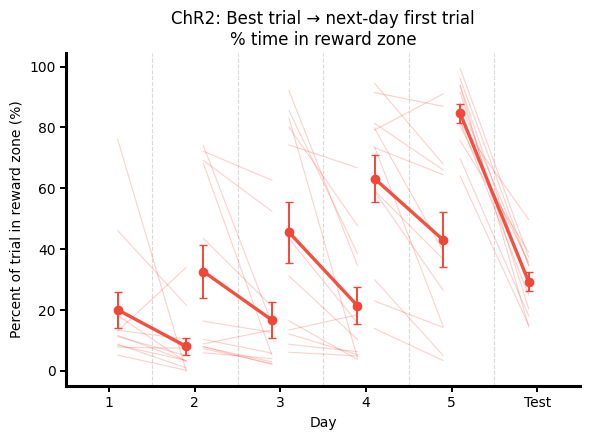

In [30]:

# ============================================================
# ChR2 only:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: pct_time_in_trigger (% trial in reward zone)
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
# ============================================================

PLOT_INDIVIDUAL = True   # False → only mean ± SEM

# ------------------------------------------------------------
# 1) Filter: usable, not short, ChR2, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[(~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = max pct_time_in_trigger within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day):
    """
    Returns a DataFrame with one row per animal:
      sub, best_val, first_val
    """
    md = meta_g[meta_g['plot_day'] == day].copy()
    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'best_val', 'first_val'])

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        # mean per trial if duplicates exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)['pct_time_in_trigger']
              .mean()
              .sort_index()
        )

        if len(by_trial) == 0:
            continue

        best_val = np.nanmax(by_trial.values)
        first_val = by_trial.get(1, np.nan)

        rows.append({
            'sub': sub,
            'best_val': best_val,
            'first_val': first_val
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best  -> day d+1 first
#    for d = 1..4, and day 5 -> day 6 (Test)
# ------------------------------------------------------------
transitions = []
for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = per_subject_day_values(meta_LT, d_prev)[['sub', 'best_val']].rename(columns={'best_val': 'y_prev'})
    next_df = per_subject_day_values(meta_LT, d_next)[['sub', 'first_val']].rename(columns={'first_val': 'y_next'})

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

# print animal counts used per transition
print("Animals included per transition:")
for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'
    print(f"  Day {d_prev} best -> {nxt_label} trial 1: n = {n}")

# ------------------------------------------------------------
# 6) Plot helper
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    if len(x) == 1:
        return x[0], 0.0
    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color('ChR2')

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr  = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    # --------------------------------------------------------
    # 1) INDIVIDUAL ANIMAL LINES (thin, underneath)
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            ax.plot(
                [x_prev, x_next],
                [row['y_prev'], row['y_next']],
                color=col,
                linewidth=0.8,
                alpha=0.25,   # faint
                zorder=1
            )

    # --------------------------------------------------------
    # 2) GROUP MEAN ± SEM (on top)
    # --------------------------------------------------------
    y_prev = df_tr['y_prev'].values
    y_next = df_tr['y_next'].values

    def mean_sem(x):
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return np.nan, np.nan
        if len(x) == 1:
            return x[0], 0.0
        return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    # mean connecting line
    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    # mean points + SEM
    ax.errorbar(
        x_prev, m_prev, yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next, m_next, yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel('Percent of trial in reward zone (%)')

ax.set_title(
    'ChR2: Best trial → next-day first trial\n'
    '% time in reward zone',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

Animals included: n = 12
    sub  Day 1 trials  Test trials
0     1             8            1
1     3             8            1
2     4             8            1
3     6             8            1
4     7             8            1
5     8             8            1
6     9             8            1
7    10             8            1
8    11             8            1
9    12             8            1
10   16             8            1
11   18             8            1

Wilcoxon signed-rank p = 0.000977
The Wilcoxon test is run on 12 paired animal means, not on all raw trial traces.


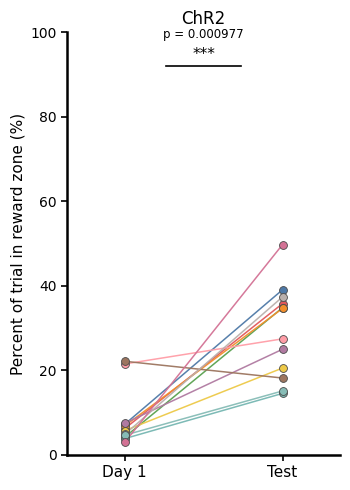

In [ ]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_test'   # 'day1_vs_test' or 'day1_vs_day5'
PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False         # False -> hide thick mean/SEM overlay
SHOW_ANIMAL_IDS = False

# individual animal colour style:
#   'pastel' -> each animal gets a different pastel colour
#   'shades' -> animals are different shades of ChR2 colour
INDIVIDUAL_COLOR_MODE = 'pastel'

# whether to draw a thin edge around each dot
DOT_EDGE = True

# ------------------------------------------------------------
# 1) Filter: usable, not short, ChR2, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[(~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) Per-subject day mean using available trials
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day):
    md = meta_g[meta_g['plot_day'] == day].copy()
    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'mean_val', 'n_trials'])

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)['pct_time_in_trigger']
              .mean()
              .sort_index()
        )

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'mean_val': np.nanmean(by_trial.values),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)

day1_df = per_subject_day_mean(meta_LT, 1)

if COMPARE_MODE == 'day1_vs_test':
    comp_df = per_subject_day_mean(meta_LT, 6)
    left_label = 'Day 1'
    right_label = 'Test'
    title_txt = 'ChR2'
elif COMPARE_MODE == 'day1_vs_day5':
    comp_df = per_subject_day_mean(meta_LT, 5)
    left_label = 'Day 1'
    right_label = 'Day 5'
    title_txt = 'ChR2'
else:
    raise ValueError("COMPARE_MODE must be 'day1_vs_test' or 'day1_vs_day5'")

paired = (
    day1_df[['sub', 'mean_val', 'n_trials']].rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']].rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'Animals included: n = {len(paired)}')
print(paired[['sub', 'n1', 'n2']].rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'}))

# ------------------------------------------------------------
# 5) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    try:
        stat_w, p_w = wilcoxon(y1, y2, alternative='two-sided')
    except ValueError:
        stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(f"\nWilcoxon signed-rank p = {p_w:.3g}" if np.isfinite(p_w) else "\nWilcoxon signed-rank p = NaN")
print(f"The Wilcoxon test is run on {len(y1)} paired animal means, not on all raw trial traces.")

# ------------------------------------------------------------
# 6) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)

def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))

def get_nature_palette(n):
    """
    Publication-style muted but visible colours.
    More solid than pastel, not overly saturated.
    """
    palette = [
        '#4E79A7',  # blue
        '#E15759',  # red
        '#59A14F',  # green
        '#F28E2B',  # orange
        '#B07AA1',  # purple
        '#76B7B2',  # teal
        '#EDC948',  # yellow
        '#FF9DA7',  # soft pink
        '#9C755F',  # brown
        '#BAB0AC',  # grey
        '#86BCB6',  # aqua muted
        '#D37295',  # rose
        '#8CD17D',  # light green
        '#F1CE63',  # warm yellow
        '#499894',  # deep teal
        '#E17C05',  # darker orange
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.6, 5.0))

base_col = get_genotype_color('ChR2')

# closer x positions
x1, x2 = 0.00, 0.55

# choose individual animal colours
n_animals = len(paired)
if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

# individual paired lines
if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'], row['y2']],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'], row['y2']],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'],
                str(row['sub']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

# optional group mean ± SEM
if PLOT_GROUP_MEAN:
    m1 = np.nanmean(y1)
    m2 = np.nanmean(y2)

    s1 = 0.0 if len(y1) <= 1 else np.nanstd(y1, ddof=1) / np.sqrt(len(y1))
    s2 = 0.0 if len(y2) <= 1 else np.nanstd(y2, ddof=1) / np.sqrt(len(y2))

    ax.plot([x1, x2], [m1, m2], '-', color=base_col, linewidth=2.4, zorder=3)
    ax.errorbar(x1, m1, yerr=s1, fmt='o', color=base_col, markersize=7, capsize=3, linewidth=1.4, zorder=4)
    ax.errorbar(x2, m2, yerr=s2, fmt='o', color=base_col, markersize=7, capsize=3, linewidth=1.4, zorder=4)

# significance line + stars + p value
y_line = 92
y_star = 93
y_pval = 98

xmid = (x1 + x2) / 2
half_len = 0.13
ax.plot([xmid - half_len, xmid + half_len], [y_line, y_line], color='k', lw=1.2, zorder=5)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

# styling
ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel('Percent of trial in reward zone (%)', fontsize=11)
ax.set_title(title_txt, fontsize=12, pad=6)

ax.set_xlim(-0.20, 0.75)
ax.set_ylim(0, 100)

style_nature(ax)
plt.tight_layout()
plt.show()

In [ ]:
# plot f231a vs wt learning trials + first test day (by session) after learning


# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2: red
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(x_vals, mean_c, yerr=sem_c, fmt='-o', color='red', alpha=0.8,
                 capsize=5, label=f'F231A (n={len(subs_ChR2)})')

# eYFP_ChR2: turquoise
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row, '-o', color='turquoise', alpha=0.1, label='_nolegend_')
    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(x_vals, mean_y, yerr=sem_y, fmt='-o', color='turquoise', alpha=0.90,
                 capsize=5, label=f'F231A_wt (n={len(subs_eYFP)})')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 0
ChR2 short animals plotted: 0


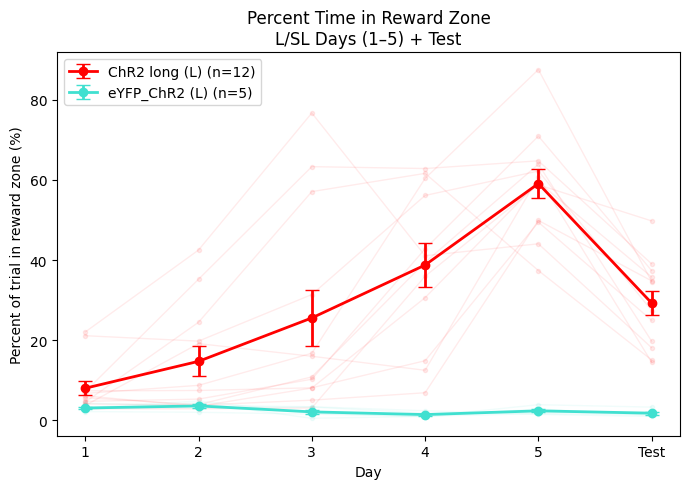

In [16]:
# =============================================================
# Build subject × day performance matrices for 3 groups:
# percent time in trigger zone over learning days + test

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a group
#    learning_type: 'L' or 'SL'
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning trials)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # genotype + (learning_type or T)
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # use 'ses' to find first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration == 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration == 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )
    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o', color=color,
        capsize=5,
        linewidth=2,
        markersize=6,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nL/SL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

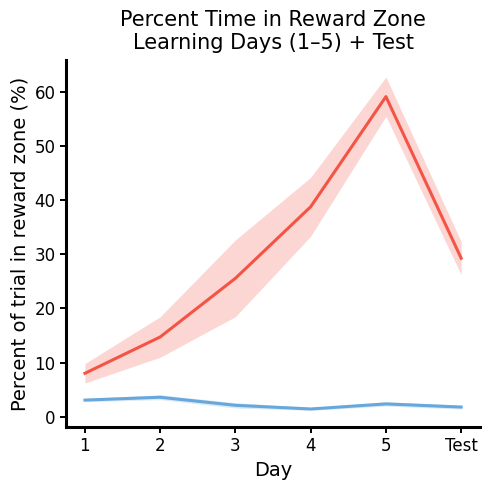

In [17]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, using colour function
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) matrix of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'ChR2_short')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces, no dots)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Group 1: ChR2 long – use 'ChR2' colour
plot_group_shaded(
    mat_ChR2_long,
    subs_ChR2_long,
    genotype_key='ChR2',
    label='ChR2 long (L)'
)

# Group 2: eYFP_ChR2 – use 'eYFP_ChR2' colour
plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2 (L)'
)

# Group 3: ChR2 short – use 'ChR2_short' colour
plot_group_shaded(
    mat_ChR2_short,
    subs_ChR2_short,
    genotype_key='ChR2_short',
    label='ChR2 short (SL)'
)


# ------------------------------------------------------------
# Axes + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days (1–5) + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

# plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in data: 12
ChR2 animals plotted: 12
eYFP animals in data: 5
eYFP animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


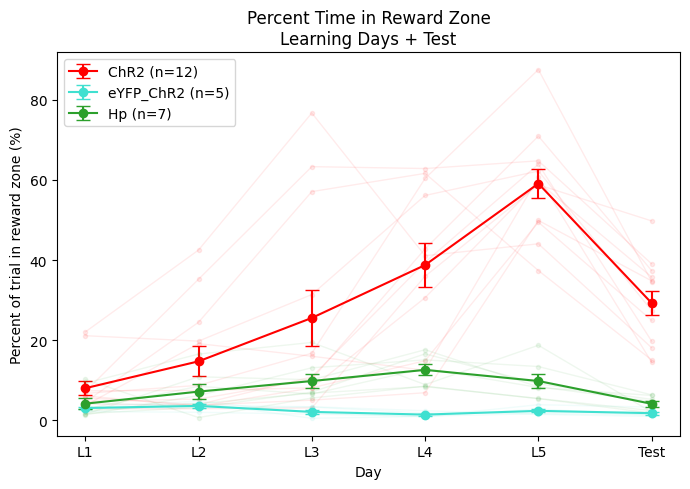

In [18]:
# plot ChR2 & eYFP_ChR2 & Hp learning trials + test after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable animals, 3 genotypes, L or T trials
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create plot_day:
# - L trials → trial_type_day 1–5
# - T trials → set later to day 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']


# ---------------------------------------------------------------------
# 1b. Assign the first T *session* after the last L session to plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6


plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test session


# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs
    Only keeps animals with complete 1–6 days.
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue   # require complete 6 days

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ---------------------------------------------------------------------
# 3. Build matrices for the three groups
# ---------------------------------------------------------------------
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp)

print("ChR2 animals in data:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP animals in data:", meta_eYFP['sub'].nunique())
print("eYFP animals plotted:", len(subs_eYFP))
print("Hp animals in data:", meta_Hp['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ---------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # individual traces
    for row in mat:
        plt.plot(x_vals, row, '-o', color=color, alpha=0.08, linewidth=1, markersize=3,label='_nolegend_')

    # group mean ± sem
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_, fmt='-o', color=color,
        capsize=5, label=f'{label} (n={len(subs)})'
    )


# Plot groups
plot_group(mat_ChR2, subs_ChR2, color='red',     label='ChR2')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c', label='Hp')


plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['L1','L2','L3','L4','L5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

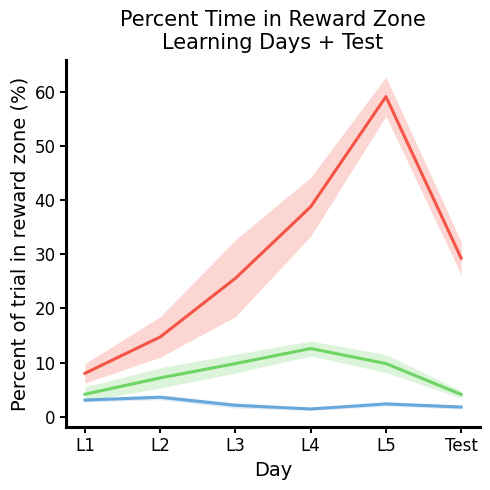

In [19]:
# ---------------------------------------------------------------------
# 4. Plot: mean ± shaded SEM, colour function, no individual traces
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'Hp')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individuals)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Plot groups with your colour scheme
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  genotype_key='Hp',
                  label='Hp')

# Axis labels, ticks, style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['L1', 'L2', 'L3', 'L4', 'L5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

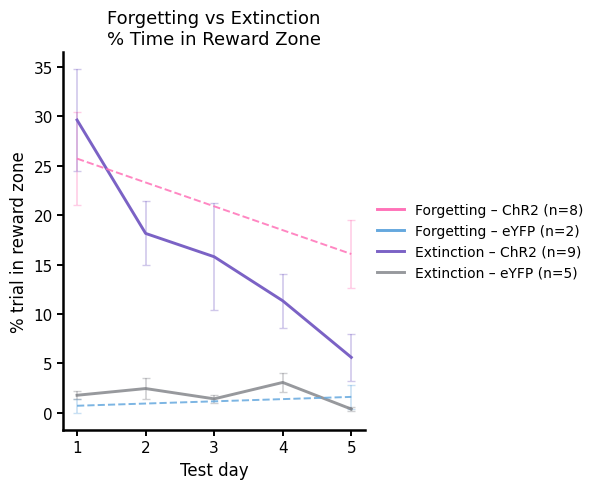

In [60]:
# ----- COMPARE FORGETTING VS EXTINCTION (ChR2 vs eYFP) -----

# ---- 1. Restrict to TEST trials, desired genotypes, and NOT short_duration ----
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

max_day = 5
day_values = np.arange(1, max_day + 1)


# ---- 2. Build subject × test-day matrix ----
def build_subject_matrix(meta_group):
    performance_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        m = meta_group[meta_group['sub'] == sub]
        mean_d = m.groupby('trial_type_day')['pct_time_in_trigger'].mean()

        vec = np.full(max_day, np.nan)
        for i, d in enumerate(day_values):
            if d in mean_d.index:
                vec[i] = mean_d.loc[d]

        # skip animals with no data at all
        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects


def mean_and_sem(mat):
    """
    Robust mean/SEM:
    - returns NaN for days where all animals are NaN
    - avoids RuntimeWarnings from nanmean / nanstd
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem  = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)

    return mean, sem


# ---- 3. Split by genotype × test_type ----
meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2']
meta_YFP  = meta_T[meta_T['genotype'] == 'eYFP_ChR2']

perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

perf_f_YFP, subs_f_YFP   = build_subject_matrix(meta_YFP[meta_YFP['test_type'] == 'forgetting'])
perf_e_YFP, subs_e_YFP   = build_subject_matrix(meta_YFP[meta_YFP['test_type'] == 'extinction'])


# ---- 4. Plot  ----
plt.figure(figsize=(7.5, 5))

#col_f_ChR2 = 'tab:red'
#col_e_ChR2 = 'tab:orange'
#col_f_YFP  = 'tab:blue'
#col_e_YFP  = 'tab:purple'
col_f_ChR2 = "#FF72B8"   # pink (forgetting)
col_e_ChR2 = '#7b62c5ff'   # pastel purple (extinction)
col_f_YFP  = "#65a8deff"
col_e_YFP  = "#76787EC1"


def plot_group(mat, color, label):
    if mat is None or mat.size == 0:
        return
    mean, sem = mean_and_sem(mat)
    if mean is None:
        return

    # line for mean
    plt.plot(
        day_values, mean,
        '-', color=color,
        linewidth=2.1,
        label=label
    )

    # faded SEM
    plt.errorbar(
        day_values, mean, yerr=sem,
        fmt='none',
        ecolor=color,
        alpha=0.35,       # more faded
        elinewidth=1.2,
        capsize=3
    )


def plot_forgetting_trend(mat, color):
    if mat is None or mat.size == 0:
        return
    mean, _ = mean_and_sem(mat)
    if mean is None:
        return
    if np.isnan(mean[0]) or np.isnan(mean[-1]):
        return
    plt.plot(
        [day_values[0], day_values[-1]],
        [mean[0], mean[-1]],
        '--',
        color=color,
        alpha=0.85,
        linewidth=1.4
    )


# forgetting
plot_group(perf_f_ChR2, col_f_ChR2, f'Forgetting – ChR2 (n={len(subs_f_ChR2)})')
plot_group(perf_f_YFP,  col_f_YFP,  f'Forgetting – eYFP (n={len(subs_f_YFP)})')

# extinction
plot_group(perf_e_ChR2, col_e_ChR2, f'Extinction – ChR2 (n={len(subs_e_ChR2)})')
plot_group(perf_e_YFP,  col_e_YFP,  f'Extinction – eYFP (n={len(subs_e_YFP)})')

# dashed forgetting trends
plot_forgetting_trend(perf_f_ChR2, col_f_ChR2)
plot_forgetting_trend(perf_f_YFP,  col_f_YFP)

# ---- Axes: NN style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('% trial in reward zone', fontsize=12)
plt.xticks(day_values, [str(d) for d in day_values], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Forgetting vs Extinction\n% Time in Reward Zone', fontsize=13, pad=6)

# ---- Legend to the right ----
plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

Per-animal Day 5 test values:
     test_type  animal  pct_time_in_trigger
0   extinction       6             3.107028
1   extinction       7             4.803077
2   extinction       8            19.859134
3   extinction      10             1.489747
4   extinction      11             3.370552
5   extinction      16             3.575044
6   extinction      18             3.091851
7   forgetting       6            15.433859
8   forgetting       7            14.348776
9   forgetting       9            35.532230
10  forgetting      10            22.356585
11  forgetting      11             7.716140
12  forgetting      12            16.890772
13  forgetting      16             3.736940
14  forgetting      18            12.542359

Forgetting (ChR2) – Day 5, n = 8
Extinction (ChR2) – Day 5, n = 7
Mann–Whitney U (Day 5 — Forgetting vs Extinction, ChR2) p = 0.014


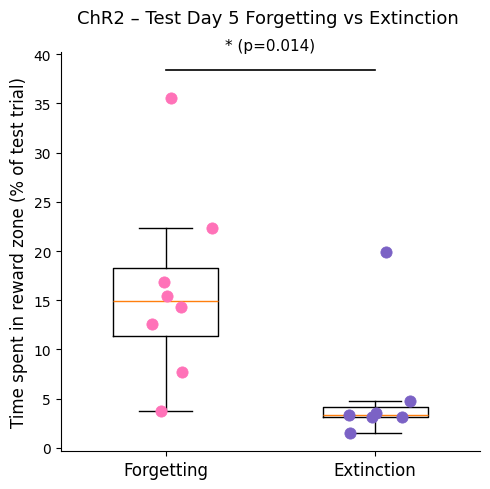

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials for ChR2, Forgetting vs Extinction, Day 5 only
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == 'ChR2') &
    (metadata['trial_type'] == 'T') &
    (metadata['short_duration'] != 1) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['test_type'].isin(['forgetting', 'extinction'])) &
    (metadata['trial_type_day'] == 5)      # ✅ Day 5 test only
].copy()

# Rename for convenience
meta_T['animal'] = meta_T['sub']

# ------------------------------------------------------------
# 2) Collapse to one point per animal per test_type (mean over T trials on Day 5)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['test_type', 'animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print("Per-animal Day 5 test values:")
print(meta_animal)

# Extract arrays
vals_f = meta_animal.loc[meta_animal['test_type'] == 'forgetting',
                         'pct_time_in_trigger'].values
vals_e = meta_animal.loc[meta_animal['test_type'] == 'extinction',
                         'pct_time_in_trigger'].values

print(f"\nForgetting (ChR2) – Day 5, n = {len(vals_f)}")
print(f"Extinction (ChR2) – Day 5, n = {len(vals_e)}")

# If one group has no animals, warn and stop
if (len(vals_f) == 0) or (len(vals_e) == 0):
    print("⚠️ One of the groups has no Day 5 test animals. "
          "Check metadata['test_type'] and trial_type_day==5.")
else:
    # --------------------------------------------------------
    # 3) Mann–Whitney U test (Forgetting vs Extinction)
    # --------------------------------------------------------
    stat, p = mannwhitneyu(vals_f, vals_e, alternative='two-sided')
    print(f"Mann–Whitney U (Day 5 — Forgetting vs Extinction, ChR2) p = {p:.3g}")

    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 0.05: return "*"
        return "n.s."

    stars = p_to_stars(p)

    # --------------------------------------------------------
    # 4) Prepare data & colors for boxplot
    # --------------------------------------------------------
    col_f_ChR2 = "#FF72B8"   # pink (forgetting)
    col_e_ChR2 = '#7b62c5ff'   # pastel purple (extinction)
    groups = ['Forgetting', 'Extinction']
    data   = [vals_f, vals_e]
    colors = [col_f_ChR2, col_e_ChR2]   # or swap to your own palette
  

    # --------------------------------------------------------
    # 5) Plot boxplot + jittered dots
    # --------------------------------------------------------
    plt.figure(figsize=(5, 5))

    bp = plt.boxplot(
        data,
        positions=np.arange(len(groups)),
        widths=0.5,
        patch_artist=False,   # outline only
        showfliers=False      # we show all animals as scatter instead
    )

    # Jittered animal points
    for i, vals in enumerate(data):
        n = len(vals)
        if n == 0:
            continue
        jitter = 0.14
        x = np.random.normal(i, jitter, size=n)

        plt.scatter(
            x, vals,
            s=65,
            color=colors[i],
            linewidth=0.6,
            zorder=3
        )

    # --------------------------------------------------------
    # 6) Significance bar between the two groups
    # --------------------------------------------------------
    ymax = np.nanmax(np.concatenate([vals_f, vals_e]))
    y_line = ymax * 1.08
    y_star = ymax * 1.13

    # horizontal bar from x=0 to x=1
    plt.plot(
        [0, 0, 1, 1],
        [y_line, y_line, y_line, y_line],
        color='black',
        linewidth=1.2
    )

    plt.text(
        0.5, y_star,
        f"{stars} (p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=11
    )

    # --------------------------------------------------------
    # 7) Axes / labels / style
    # --------------------------------------------------------
    plt.xticks(np.arange(len(groups)), groups, fontsize=12)
    plt.ylabel('Time spent in reward zone (% of test trial)', fontsize=12)
    plt.xlabel('')
    plt.title('ChR2 – Test Day 5 Forgetting vs Extinction \n', fontsize=13)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# plot forgetting/extinction in the order they were carried out

# 1. Filter metadata to test trials & assign test_round from test_order
# ============================================================

# Keep only test trials, the two genotypes, and non-short-duration
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1)
].copy()

# Make sure test_order is string
meta_T['test_order'] = meta_T['test_order'].astype(str)

# Initialise test_round
meta_T['test_round'] = np.nan  # will be 1 or 2

# Rules:
# ef: extinction first, forgetting second
# fe: forgetting first, extinction second
# e:  only extinction → all extinction = round 1
# ee: two extinction rounds → split by day into first half / second half
# ff: two forgetting rounds → same as above
for sub in meta_T['sub'].unique():
    sub_mask = (meta_T['sub'] == sub)
    sub_rows = meta_T[sub_mask].sort_values('trial_type_day')

    if len(sub_rows) == 0:
        continue

    order = sub_rows['test_order'].iloc[0]

    # ef: extinction first, forgetting second
    if order == 'ef':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 2

    # fe: forgetting first, extinction second
    elif order == 'fe':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'forgetting'), 'test_round'] = 1
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 2

    # e: only extinction → all extinction trials are round 1
    elif order == 'e':
        meta_T.loc[sub_mask & (meta_T['test_type'] == 'extinction'), 'test_round'] = 1

    # ee: two extinction rounds → split by day into first half / second half
    elif order == 'ee':
        e_rows = sub_rows[sub_rows['test_type'] == 'extinction'].sort_values('trial_type_day')
        idx = e_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))  # first ~half = round 1
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # ff: two forgetting rounds → split by day into first half / second half
    elif order == 'ff':
        f_rows = sub_rows[sub_rows['test_type'] == 'forgetting'].sort_values('trial_type_day')
        idx = f_rows.index.to_numpy()
        n = len(idx)
        if n > 0:
            split = int(np.ceil(n / 2))
            first_half = idx[:split]
            second_half = idx[split:]
            meta_T.loc[first_half, 'test_round'] = 1
            if len(second_half) > 0:
                meta_T.loc[second_half, 'test_round'] = 2

    # else: unknown test_order → leave as NaN (ignored later)

max_day = 5
day_values = np.arange(1, max_day + 1)  # [1..5]


# ============================================================
# 2. Helper functions
# ============================================================

def build_subject_matrix(meta_group):
    """
    For a given subset (e.g. ChR2 + forgetting + round1),
    return:
      - performance_mat: (n_subjects x max_day) array with NaNs for missing days
      - subjects_used: list of subject IDs included

    Skips subjects that only have day 1 in this subset.
    """
    performance_mat = []
    subjects_used = []

    for sub in meta_group['sub'].unique():
        meta_sub = meta_group[meta_group['sub'] == sub]

        if len(meta_sub) == 0:
            continue

        # Mean % time in trigger zone per test day for this subject
        mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
        days_present = np.array(sorted(mean_pct_by_day.index.values))

        # Exclude subjects with only day 1 in this condition
        if (len(days_present) == 1) and (days_present[0] == 1):
            continue

        subj_vec = np.full(max_day, np.nan)
        for i, day in enumerate(day_values):
            if day in mean_pct_by_day.index:
                subj_vec[i] = mean_pct_by_day.loc[day]

        if np.isnan(subj_vec).all():
            continue

        performance_mat.append(subj_vec)
        subjects_used.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects_used


def mean_and_sem(mat):
    """Mean ± SEM across subjects, per day, handling all-NaN columns."""
    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)
    return mean, sem


def plot_round(meta_T_full, round_num, title_prefix, y_limits=None):
    """Make a plot for test round 1 or 2."""
    meta_round = meta_T_full[meta_T_full['test_round'] == round_num].copy()
    if len(meta_round) == 0:
        print(f'No data for test_round {round_num}')
        return

    # split by genotype
    meta_ChR2 = meta_round[meta_round['genotype'] == 'ChR2']
    meta_eYFP = meta_round[meta_round['genotype'] == 'eYFP_ChR2']

    # build matrices for genotype × test_type
    perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'forgetting'])
    perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
        meta_ChR2[meta_ChR2['test_type'] == 'extinction'])

    perf_f_YFP, subs_f_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'forgetting'])
    perf_e_YFP, subs_e_YFP = build_subject_matrix(
        meta_eYFP[meta_eYFP['test_type'] == 'extinction'])

    # colors
    col_f_ChR2 = 'tab:red'       # soft red
    col_f_YFP = 'tab:blue'       # blue
    col_e_ChR2 = 'tab:orange'    # orange
    col_e_YFP = 'tab:purple'     # purple

    plt.figure()

    # ----- individual traces -----
    if perf_f_ChR2 is not None:
        for i in range(perf_f_ChR2.shape[0]):
            plt.plot(day_values, perf_f_ChR2[i, :],
                     '-o', color=col_f_ChR2, alpha=0.25, label='_nolegend_')

    if perf_e_ChR2 is not None:
        for i in range(perf_e_ChR2.shape[0]):
            plt.plot(day_values, perf_e_ChR2[i, :],
                     '-o', color=col_e_ChR2, alpha=0.25, label='_nolegend_')

    if perf_f_YFP is not None:
        for i in range(perf_f_YFP.shape[0]):
            plt.plot(day_values, perf_f_YFP[i, :],
                     '-o', color=col_f_YFP, alpha=0.25, label='_nolegend_')

    if perf_e_YFP is not None:
        for i in range(perf_e_YFP.shape[0]):
            plt.plot(day_values, perf_e_YFP[i, :],
                     '-o', color=col_e_YFP, alpha=0.25, label='_nolegend_')

    # ----- group means ± SEM -----
    mean_f_ChR2 = mean_f_YFP = None

    if perf_f_ChR2 is not None:
        mean_f_ChR2, sem = mean_and_sem(perf_f_ChR2)
        plt.errorbar(day_values, mean_f_ChR2, yerr=sem,
                     fmt='-o', color=col_f_ChR2, capsize=5,
                     label='Forgetting – ChR2')

    if perf_e_ChR2 is not None:
        mean, sem = mean_and_sem(perf_e_ChR2)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_ChR2, capsize=5,
                     label='Extinction – ChR2')

    if perf_f_YFP is not None:
        mean_f_YFP, sem = mean_and_sem(perf_f_YFP)
        plt.errorbar(day_values, mean_f_YFP, yerr=sem,
                     fmt='-o', color=col_f_YFP, capsize=5,
                     label='Forgetting – eYFP_ChR2')

    if perf_e_YFP is not None:
        mean, sem = mean_and_sem(perf_e_YFP)
        plt.errorbar(day_values, mean, yerr=sem,
                     fmt='-o', color=col_e_YFP, capsize=5,
                     label='Extinction – eYFP_ChR2')

    # dashed Day1–Day5 for forgetting group means (ChR2 & eYFP)
    if mean_f_ChR2 is not None and not np.isnan(mean_f_ChR2[0]) and not np.isnan(mean_f_ChR2[4]):
        plt.plot([1, 5], [mean_f_ChR2[0], mean_f_ChR2[4]],
                 '--', color=col_f_ChR2, alpha=0.9)

    if mean_f_YFP is not None and not np.isnan(mean_f_YFP[0]) and not np.isnan(mean_f_YFP[4]):
        plt.plot([1, 5], [mean_f_YFP[0], mean_f_YFP[4]],
                 '--', color=col_f_YFP, alpha=0.9)

    # sample sizes
    n_f_ChR2 = len(subs_f_ChR2)
    n_e_ChR2 = len(subs_e_ChR2)
    n_f_YFP = len(subs_f_YFP)
    n_e_YFP = len(subs_e_YFP)

    title_str = (
        f'{title_prefix} – % Time in Trigger Zone\n'
        f'ChR2: F={n_f_ChR2}, E={n_e_ChR2} | '
        f'eYFP_ChR2: F={n_f_YFP}, E={n_e_YFP}'
    )

    plt.title(title_str)
    plt.xlabel('Test Day (trial_type_day)')
    plt.ylabel('Percent of trial in trigger zone (%)')
    plt.xticks(day_values, [f'Day {d}' for d in day_values])
    plt.legend()

    # apply shared y-limits if provided
    if y_limits is not None:
        plt.ylim(y_limits)

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. Compute shared y-axis limits across ALL test trials
# ============================================================

valid_vals = meta_T['pct_time_in_trigger'].values
valid_vals = valid_vals[~np.isnan(valid_vals)]

if len(valid_vals) > 0:
    y_min = 0
    y_max = 62
    #y_max = np.nanmax(valid_vals)
    y_limits = (y_min, y_max * 1.1)  # little headroom
else:
    y_limits = None  # fallback


# ============================================================
# 4. Make the two figures: round 1 and round 2 (shared y-axis)
# ============================================================

plot_round(
    meta_T,
    round_num=1,
    title_prefix='Round 1 tests (first forgetting/extinction block)',
    y_limits=y_limits
)

plot_round(
    meta_T,
    round_num=2,
    title_prefix='Round 2 tests (second forgetting/extinction block)',
    y_limits=y_limits
)

Compute percentage of time spent in each reward zone

In [64]:
# ----- COMPUTE PERCENT TIME IN TRIGGER ZONE (PER TRIGGER) -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone (like your example)
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

pct_rows = []  # will hold per-trigger rows: trial_id, trigger_id, pct_in_trigger_trig

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Trial duration (same units as df_trigger_interaction['duration'])
    trial_duration = position_['t'].max()
    if trial_duration <= 0:
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # ---- ANY trigger, like your original code ----
    total_time_in_trigger = df_all_triggers['duration'].sum()
    pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger

    # ---- PER TRIGGER: same logic, but restricted to each trigger_id ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
        if len(df_t) == 0:
            pct_trig = 0.0   # spent 0% of time in this trigger
        else:
            total_t_trig = df_t['duration'].sum()
            pct_trig = 100.0 * total_t_trig / trial_duration

        pct_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'pct_in_trigger_trig': pct_trig
        })

# Long-format per-trigger table + metadata
df_pct = pd.DataFrame(pct_rows)
meta_pct = df_pct.merge(metadata, left_on='trial_id', right_index=True, how='left')

 15%|█▌        | 702/4609 [00:07<00:38, 100.50it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1183/4609 [00:11<00:30, 111.52it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2605/4609 [00:24<00:12, 156.79it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4609/4609 [00:40<00:00, 113.09it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


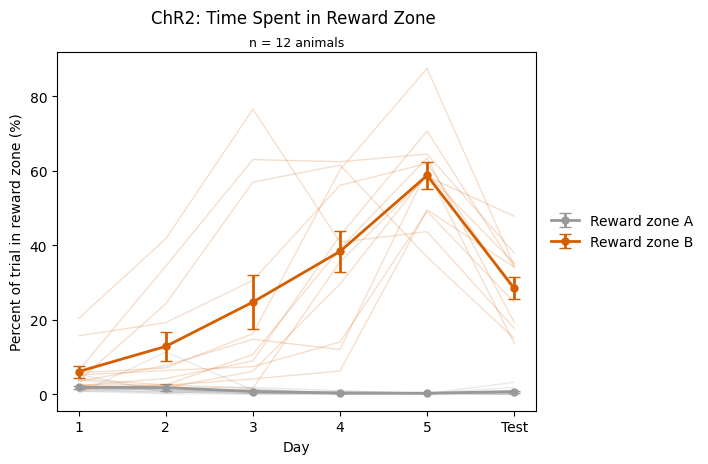

In [22]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['L', 'T']))
].copy()

# L days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L trials
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (PERCENT TIME) -----

def build_zone_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix_pct(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style colors for A/B
colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded) + ID labels at end
    for row, sub in zip(mat, subs):
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )


    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

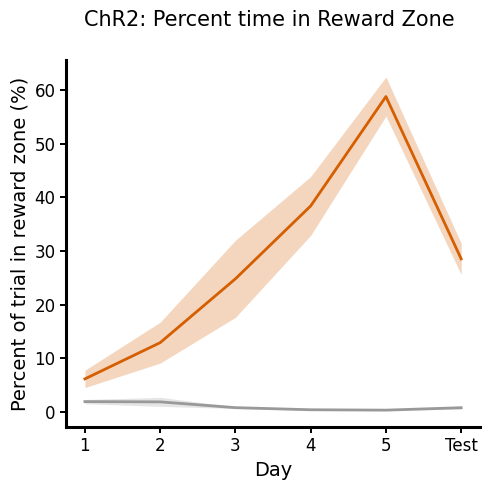

In [23]:
# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1   # 0..5 index for days 1–6

colors = {
    1: '#999999',  # zone A
    2: '#D55E00',  # zone B
}
#labels = {
#    1: 'Reward zone A',
#    2: 'Reward zone B',
#}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[zid]

    # ---- shaded SEM ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[zid]} (n={len(subs)})"
    )

# ----- axis + styling -----
ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test'],
    fontsize=12
)

plt.yticks(fontsize=12)

# thick bottom/left, hide top/right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent time in Reward Zone \n', fontsize=15, pad=8)

# small n info
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included per reward zone:
  Reward zone 1: 12 animals
  Reward zone 2: 12 animals

Total unique animals included (any zone): 12
Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


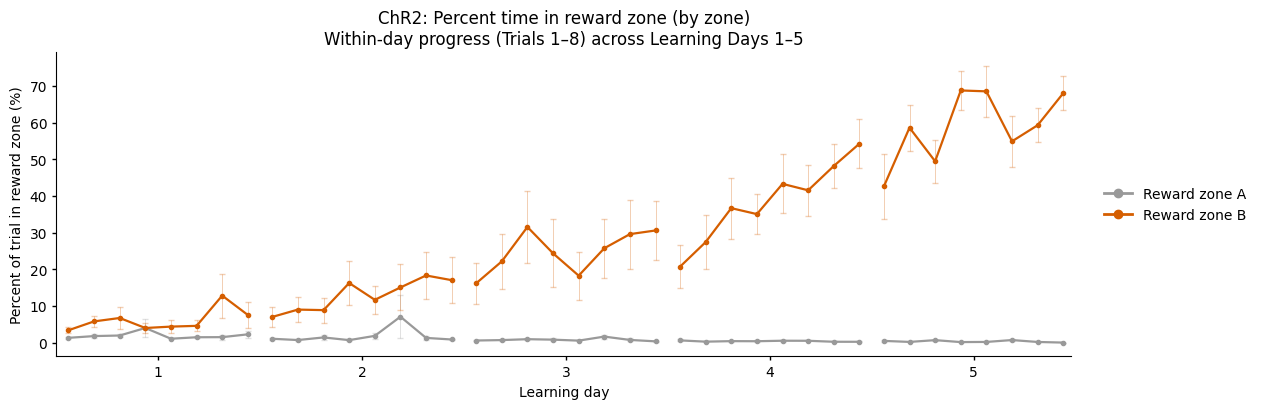

In [49]:
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_in_trigger_trig (% of trial in reward zone)
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2 (Reward zone A/B)
# Notes:
#   - excludes short_duration == 1
#   - allows missing trials within a day (curve uses available points)
#   - no individual background traces (mean ± SEM only)
# ============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

# ------------------------------------------------------------
# 1) Filter meta_pct: ChR2, L only, days 1–5, NOT short
# ------------------------------------------------------------
meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'L') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS (not rows)
#    so trigger A and B share the same trial number
# ------------------------------------------------------------

# Use a stable per-trial key
if 'trial_id' not in meta_L.columns:
    # fallback: if you don't have trial_id, use the index as trial id
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

# Build a per-trial table (one row per real trial)
trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial numbers within each session (or within each day — see note below)
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trials 1..8
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

# Merge back so BOTH triggers get the SAME trial_in_day
meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day AND zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id):
    md = meta_g[(meta_g['trial_type_day'] == day) & (meta_g['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, meta_g, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        meta_L,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Center ticks under each day curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Make sure day 5 curve fully visible and reduce left whitespace
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'ChR2: Percent time in reward zone (by zone)\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='#999999', lw=2, marker='o', label='Reward zone A'),
    Line2D([0], [0], color='#D55E00', lw=2, marker='o', label='Reward zone B'),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Animal counts (based on *this* filtered dataset)
# ------------------------------------------------------------
subs_zone = {
    zid: sorted(meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}

print("Animals included per reward zone:")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


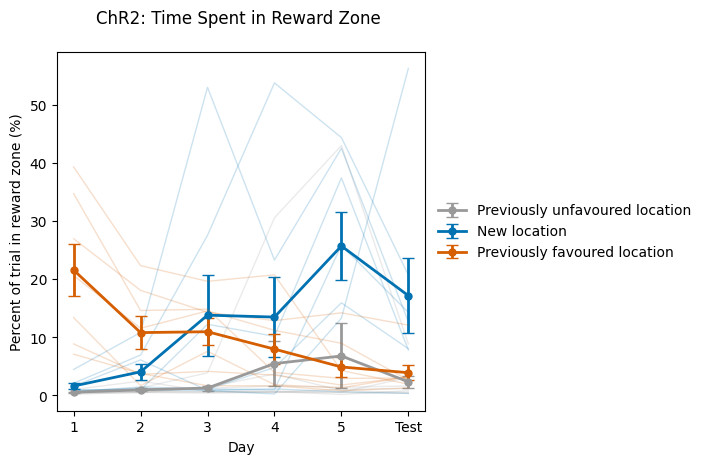

In [ ]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# RL days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL trials
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last RL session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (PERCENT TIME) -----

def build_trigger_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean % time per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_pct(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row,                      # already in %
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

# Main title + smaller n-line
plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


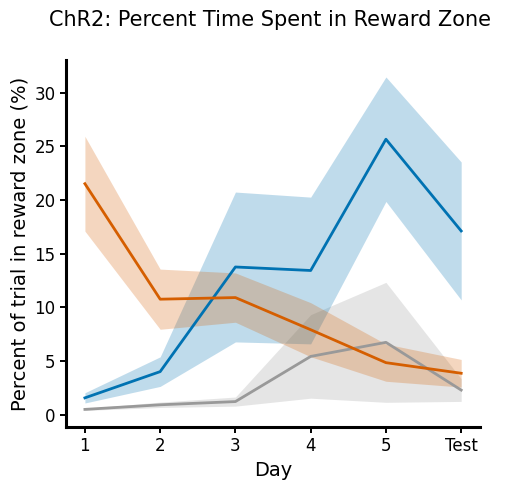

In [26]:
# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat  = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[trig_id]

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers, no individuals) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[trig_id]} (n={len(subs)})"
    )

ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

# journal-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent Time Spent in Reward Zone \n', fontsize=15, pad=8)

# small n text if you still want it
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

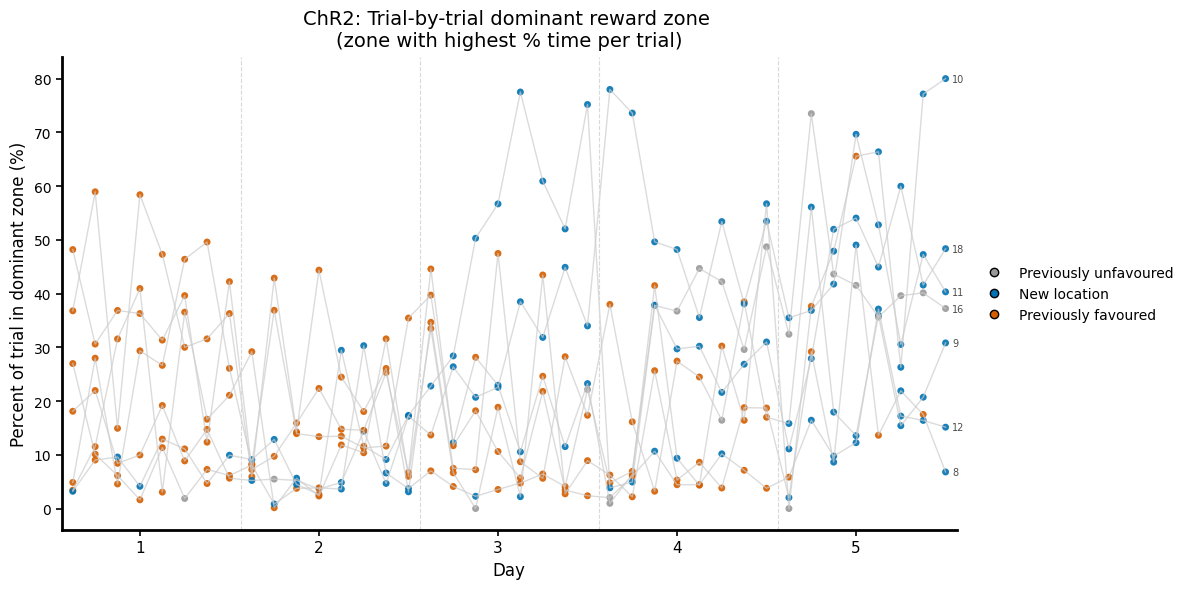

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1) Build RL dataset for plot_day 1–5 only
# ============================================================

mt = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'RL') &
    (meta_pct['trial_type_day'].between(1,5)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# RL days map directly
mt['plot_day'] = mt['trial_type_day']

plot_days = np.arange(1, 6)   # only RL days

# ============================================================
# 2) Ensure trial_in_day (1..8) shared across zones
# ============================================================

candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is None:
    if 'trial_id' not in mt.columns:
        mt = mt.reset_index().rename(columns={'index': 'trial_id'})
    trial_table = (
        mt[['trial_id', 'sub', 'ses', 'plot_day']]
        .drop_duplicates('trial_id')
        .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
        .copy()
    )
    trial_table['trial_in_day'] = trial_table.groupby(['sub','ses']).cumcount() + 1
    mt = mt.merge(trial_table[['trial_id','trial_in_day']], on='trial_id', how='inner')
else:
    mt['trial_in_day'] = mt[trial_col].astype(int)

mt = mt[mt['trial_in_day'].between(1,8)].copy()

# ============================================================
# 3) Dominant (max %) zone per trial
# ============================================================

if 'trial_id' in mt.columns:
    group_key = 'trial_id'
else:
    group_key = ['sub','ses','plot_day','trial_in_day']

idx_max = mt.groupby(group_key)['pct_in_trigger_trig'].idxmax()
dominant = mt.loc[idx_max].copy()

dominant['trial_idx_global'] = (dominant['plot_day'] - 1) * 8 + dominant['trial_in_day']

# ============================================================
# 4) Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12,6))

zone_colors = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new
    3: '#D55E00',  # previously favoured
}

zone_labels = {
    1: 'Previously unfavoured',
    2: 'New location',
    3: 'Previously favoured',
}

for sub in sorted(dominant['sub'].unique()):
    ms = dominant[dominant['sub']==sub].sort_values(['plot_day','trial_in_day'])
    x = ms['trial_idx_global'].values
    y = ms['pct_in_trigger_trig'].values

    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    for zid in [1,2,3]:
        ms_z = ms[ms['trigger_id']==zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                ms_z['pct_in_trigger_trig'].values,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ============================================================
# 5) Cosmetics - RL only
# ============================================================

max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day

for d in range(1, max_day):
    ax.axvline(d*trials_per_day + 0.5, color='0.85', linestyle='--', linewidth=0.8)

day_centers = [(d-0.5)*trials_per_day for d in range(1, max_day+1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day+1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Percent of trial in dominant zone (%)', fontsize=12)

# --- legend to the right of the figure ---
handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor=zone_colors[zid],
           markersize=6, label=zone_labels[zid])
    for zid in [1,2,3]
]

ax.legend(
    handles=handles,
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title(
    'ChR2: Trial-by-trial dominant reward zone \n'
    '(zone with highest % time per trial)',
    fontsize=14, pad=8
)

plt.tight_layout()
plt.show()


Animals with data in ALL three zones on Test day: n=7
Animal IDs: [8, 9, 10, 11, 12, 16, 18]

Friedman test across zones (paired): χ² = 6, p = 0.0498
Z1 vs Z2: Wilcoxon raw p = 0.0781
Z1 vs Z3: Wilcoxon raw p = 0.219
Z2 vs Z3: Wilcoxon raw p = 0.0781

FDR-corrected p-values (Benjamini–Hochberg):
  Z1 vs Z2: p_FDR = 0.117
  Z1 vs Z3: p_FDR = 0.219
  Z2 vs Z3: p_FDR = 0.117


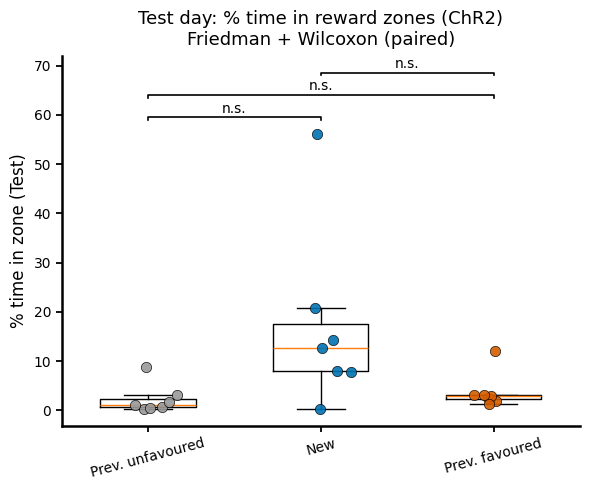

In [ ]:
# STATISTICAL TESTS: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----
from scipy.stats import friedmanchisquare, wilcoxon

# Attempt import statsmodels for FDR
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR skipped (raw p-values used).")

# --------------------------------------------------------------
# 1) Build per-animal TEST DAY values for all three zones (paired)
# --------------------------------------------------------------
groups   = ["Prev. unfavoured", "New", "Prev. favoured"]
zone_ids = [1, 2, 3]

# mat_trig[zid]: (n_animals_zid x 6 days) of % time
# subs_trig[zid]: list of animal IDs in the same order as rows of mat_trig[zid]

zone_dicts = {}  # zid -> {sub: test_day_value}
for zid in zone_ids:
    mat = mat_trig.get(zid, None)
    subs = subs_trig.get(zid, [])
    if mat is None or len(subs) == 0:
        zone_dicts[zid] = {}
        continue

    # column 5 = Test day (index 5 if days are [RL1..5, Test])
    test_vals = mat[:, 5]
    d = {}
    for sub, v in zip(subs, test_vals):
        if not np.isnan(v):
            # cast sub to int if it's np.int64
            d[int(sub)] = float(v)
    zone_dicts[zid] = d

# intersection: animals that have data in ALL THREE zones
common_subs = sorted(
    set(zone_dicts[1].keys())
    & set(zone_dicts[2].keys())
    & set(zone_dicts[3].keys())
)

print(f"\nAnimals with data in ALL three zones on Test day: n={len(common_subs)}")
print("Animal IDs:", common_subs)

# Build aligned value arrays (paired)
vals = []   # one array per zone, same length = n_animals
for zid in zone_ids:
    arr = np.array([zone_dicts[zid][sub] for sub in common_subs], dtype=float)
    vals.append(arr)

# For convenience
vals_z1, vals_z2, vals_z3 = vals

# --------------------------------------------------------------
# 2) Friedman test (global repeated-measures effect)
# --------------------------------------------------------------
if len(common_subs) > 0:
    stat_f, p_f = friedmanchisquare(vals_z1, vals_z2, vals_z3)
    print(f"\nFriedman test across zones (paired): χ² = {stat_f:.3g}, p = {p_f:.3g}")
else:
    p_f = np.nan
    print("\nFriedman test not computed (no overlapping animals).")

# --------------------------------------------------------------
# 3) Pairwise Wilcoxon signed-rank + FDR
# --------------------------------------------------------------
def wilcoxon_safe(a, b):
    """Paired Wilcoxon with NaN handling."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    mask = ~np.isnan(a) & ~np.isnan(b)
    if mask.sum() < 1:
        return np.nan
    # wilcoxon requires at least one non-zero difference; try/catch for safety
    try:
        stat, p = wilcoxon(a[mask], b[mask])
    except ValueError:
        # e.g. all differences are zero
        p = 1.0
    return p

comparisons = [
    ("Z1 vs Z2", 0, 1, vals_z1, vals_z2),
    ("Z1 vs Z3", 0, 2, vals_z1, vals_z3),
    ("Z2 vs Z3", 1, 2, vals_z2, vals_z3),
]

p_raw = []
for name, _, _, v1, v2 in comparisons:
    p = wilcoxon_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: Wilcoxon raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction
if HAS_SM:
    mask = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask.any():
        _, p_corr, _, _ = multipletests(p_raw[mask], alpha=0.05, method='fdr_bh')
        p_adj[mask] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values (no FDR).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# --------------------------------------------------------------
# 4) Boxplot + jitter (using the aligned vals)
# --------------------------------------------------------------
positions = np.arange(len(groups))

colors = {
    0: '#999999',   # Z1
    1: '#0072B2',   # Z2
    2: '#D55E00'    # Z3
}

fig, ax = plt.subplots(figsize=(6, 5))

# plain boxes, no fliers
bp = ax.boxplot(
    vals,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, v in enumerate(vals):
    if len(v) == 0:
        continue
    x = np.random.normal(positions[i], 0.08, size=len(v))
    ax.scatter(
        x, v,
        s=55,
        color=colors[i],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# --------------------------------------------------------------
# 5) Draw pairwise significance bars (using p_adj)
# --------------------------------------------------------------
all_vals = np.concatenate([v for v in vals if len(v) > 0])
ymax = np.nanmax(all_vals)
ystep = 0.08 * ymax
current_y = ymax * 1.05

for (name, i, j, _, _), p in zip(comparisons, p_adj):
    if np.isnan(p):
        continue
    stars = p_to_stars(p)

    # horizontal bar
    ax.plot(
        [i, i, j, j],
        [current_y, current_y + 0.01 * ymax,
         current_y + 0.01 * ymax, current_y],
        color='k',
        linewidth=1.2
    )

    # label (just stars; if you also want p, use f"{stars}\n(p={p:.3g})")
    ax.text(
        (i + j) / 2,
        current_y + 0.015 * ymax,
        stars,
        ha='center',
        va='bottom',
        fontsize=10
    )

    current_y += ystep

# --------------------------------------------------------------
# 6) Style / labels
# --------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('% time in zone (Test)', fontsize=12)
ax.set_title('Test day: % time in reward zones (ChR2)\nFriedman + Wilcoxon (paired)', fontsize=13, pad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', width=1.3, length=4)

plt.tight_layout()
plt.show()


=== Previously unfavoured ===
Paired animals: n = 7
Animals used: [ 8  9 10 11 12 16 18]
Wilcoxon (Day1 vs Day5): p = 0.297

=== New location ===
Paired animals: n = 7
Animals used: [ 8  9 10 11 12 16 18]
Wilcoxon (Day1 vs Day5): p = 0.0312

=== Previously favoured ===
Paired animals: n = 7
Animals used: [ 8  9 10 11 12 16 18]
Wilcoxon (Day1 vs Day5): p = 0.0156


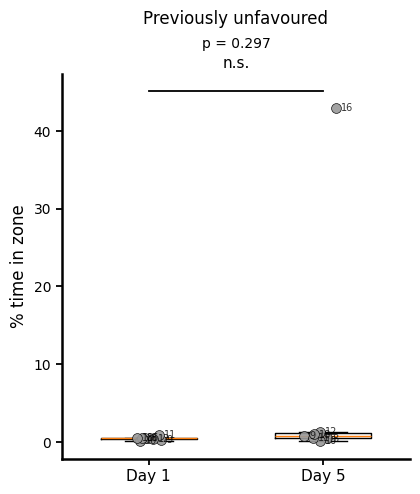

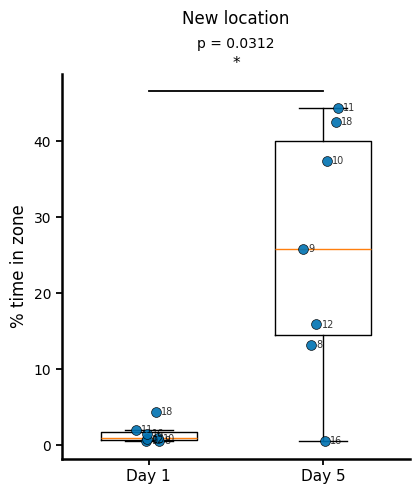

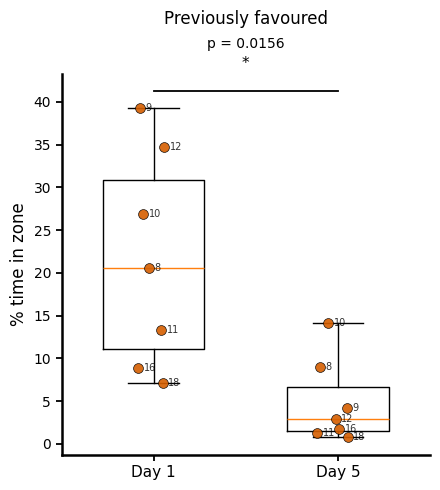

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

zone_names = {
    1: "Previously unfavoured",
    2: "New location",
    3: "Previously favoured",
}

colors = {
    1: "#999999",   # grey
    2: "#0072B2",   # blue
    3: "#D55E00",   # orange
}

day1_idx = 0   # RL day 1
day5_idx = 4   # RL day 5

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

for zid in [1, 2, 3]:

    mat = mat_trig[zid]
    subs = np.array(subs_trig[zid])

    # --- extract data for RL day1 + day5 ---
    vals_day1 = mat[:, day1_idx]
    vals_day5 = mat[:, day5_idx]

    # keep only paired animals
    mask = (~np.isnan(vals_day1)) & (~np.isnan(vals_day5))
    d1 = vals_day1[mask]
    d5 = vals_day5[mask]
    subs_used = subs[mask]

    print(f"\n=== {zone_names[zid]} ===")
    print(f"Paired animals: n = {len(d1)}")
    print("Animals used:", subs_used)

    # --- paired test ---
    if len(d1) > 0:
        stat, p = wilcoxon(d1, d5, alternative='two-sided')
        print(f"Wilcoxon (Day1 vs Day5): p = {p:.3g}")
    else:
        p = np.nan
        print("No data for paired test")

    stars = p_to_stars(p)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(4.5, 5))
    data = [d1, d5]
    labels = ["Day 1", "Day 5"]
    pos = [0, 1]

    # boxplot
    ax.boxplot(
    data,
    positions=pos,
    widths=0.55,
    patch_artist=False,
    showfliers=False,
    )

    SHOW_IDS = True   # toggle ON/OFF for animal ID next to dot

    # jitter points
    jitter = 0.06
    for i, vals in enumerate(data):
        x = np.random.normal(pos[i], jitter, size=len(vals))
        ax.scatter(
            x, vals,
            s=50,
            color=colors[zid],
            edgecolor='k',
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

        if SHOW_IDS:
            for xx, yy, sub in zip(x, vals, subs_used):
                ax.text(
                    xx + 0.03, yy,
                    str(int(sub)),
                    fontsize=7,
                    alpha=0.8,
                    va='center'
                )

    # significance line + stars + p-value
    if len(d1) > 0:
        ymax = np.nanmax(np.concatenate(data))
        y_line  = ymax * 1.05
        y_star  = ymax * 1.12
        y_pval  = ymax * 1.18
    # straight line only
        ax.plot([pos[0], pos[1]],
            [y_line, y_line],
            color='k', lw=1.3)

    # stars
    ax.text(
        (pos[0] + pos[1]) / 2,
        y_star,
        stars,
        ha='center',
        fontsize=11
    )

    # numeric p-value
    ax.text(
        (pos[0] + pos[1]) / 2,
        y_pval,
        f"p = {p:.3g}",
        ha='center',
        fontsize=10
    )

    # cosmetics
    ax.set_xticks(pos)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('% time in zone', fontsize=12)
    ax.set_title(
    f"{zone_names[zid]}\n \n",
    fontsize=12,
    pad=6
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', width=1.3, length=4)

plt.tight_layout()
plt.show()


Animals included per reward zone (RL + Test):
  Reward zone 1: 7 animals
  Reward zone 2: 7 animals
  Reward zone 3: 7 animals

Total unique animals included (any zone): 7
Animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_57264/1414558956.py:122: RuntimeWarning: Mean of empty slice
  mean_ = np.nanmean(mat, axis=0)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


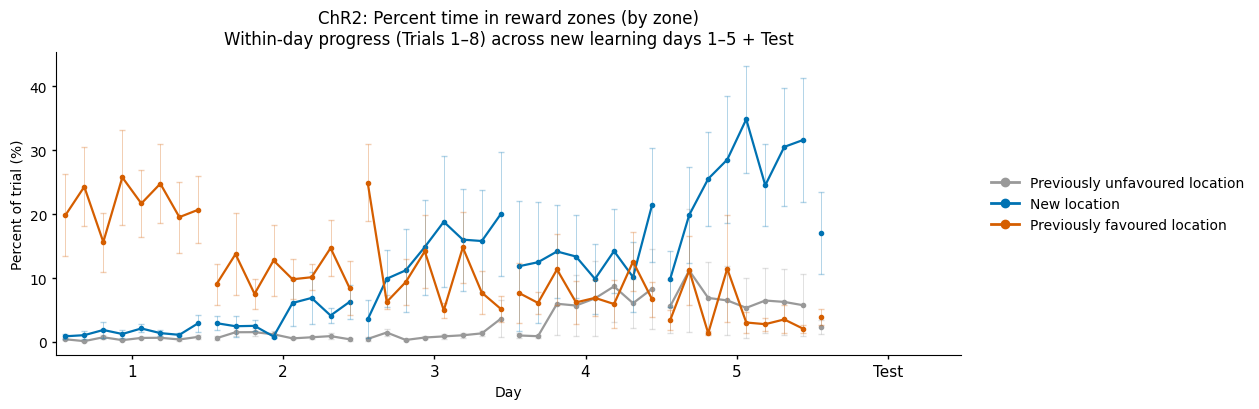

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Trial-by-trial % time in each reward zone
# RL days 1–5 + first T session as Test day 6
# Group: ChR2, using meta_pct (pct_in_trigger_trig)
# Zones: trigger_id 1, 2, 3
# ============================================================

# ----------------------------
# 1) Base filter: RL + T
# ----------------------------
mt = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T'])) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ----------------------------
# 2) Assign plot_day:
#    RL → 1–5 (from trial_type_day)
#    T  → 6 (first T session AFTER last RL for each animal)
# ----------------------------
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

# assign Test day (6) per animal using session structure
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ----------------------------
# 3) Create trial_in_day = 1..8 per session
#    (shared by all trigger zones)
# ----------------------------
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index': 'trial_id'})

trial_table = (
    mt[['trial_id', 'sub', 'ses', 'plot_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
    .copy()
)

trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

mt = mt.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ----------------------------
# 4) Helper: subject × trial matrix for a given plot_day & zone
# ----------------------------
days = plot_days        # [1..6]
trials = np.arange(1, 9)
zone_ids = [1, 2, 3]

def subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id):
    md = mt_all[(mt_all['plot_day'] == day) &
                (mt_all['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials],
                        dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ----------------------------
# 5) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ----------------------------
def plot_within_day_curves_for_zone(ax, mt_all, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points per day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ----------------------------
# 6) Plot
# ----------------------------
colors = {
    1: '#999999',  # Previously unfavoured
    2: '#0072B2',  # New / current favoured location
    3: '#D55E00',  # Previously favoured
}
labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        mt,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Day')
ax.set_ylabel('Percent of trial (%)')

# center ticks under each day block
ax.set_xticks(days + 0.5)
ax.set_xticklabels(
    ['1', '2', '3', '4', '5', 'Test'],
    fontsize=11
)

ax.set_xlim(1.0, 6.98)

ax.set_title(
    'ChR2: Percent time in reward zones (by zone)\n'
    'Within-day progress (Trials 1–8) across new learning days 1–5 + Test',
    fontsize=12
)

# journal / NN style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=3, width=1)
ax.grid(False)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=colors[1], lw=2, marker='o', label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=2, marker='o', label=labels[2]),
    Line2D([0], [0], color=colors[3], lw=2, marker='o', label=labels[3]),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# animal counts per zone (for info)
subs_zone = {
    zid: sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}
print("Animals included per reward zone (RL + Test):")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

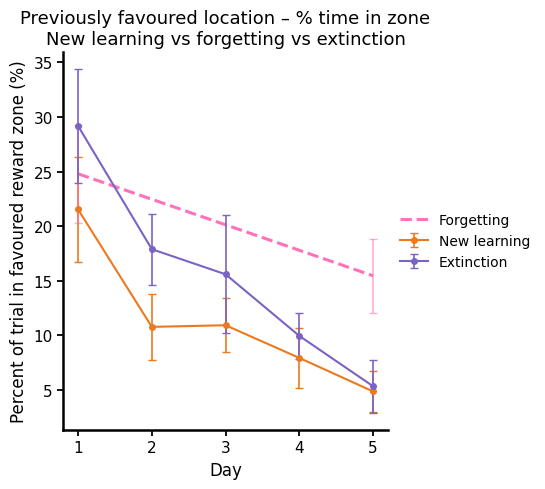

In [ ]:
# plot pct time spent in previously favoured location for new learning vs forgetting/extinction

# ============================================================
# 1) RL stage – % time in previously favoured location (trigger 3)
# ============================================================

# Start from RL/T filter in meta_pct
mt_rl = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl['plot_day'] = np.nan

mask_RL = (mt_rl['trial_type'] == 'RL')
mt_rl.loc[mask_RL, 'plot_day'] = mt_rl.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl = mt_rl[(~mask_RL) | (mt_rl['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# (We don't actually need T=6 for this plot, but we keep the logic parallel)
for sub in mt_rl['sub'].unique():
    ms = mt_rl[mt_rl['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl.index[
        (mt_rl['sub'] == sub) &
        (mt_rl['trial_type'] == 'T') &
        (mt_rl['ses'] == first_T_ses)
    ]
    mt_rl.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_stats_pct(mt_rl, trigger_id=3):
    """
    Percent of trial spent in 'previously favoured' trigger (id=3)
    for RL days 1–5, averaged:
      1) per subject per day
      2) across subjects
    Returns mean_pct, sem_pct (arrays of length 5).
    """
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['plot_day'].isin(rl_days)) &
        (mt_rl['pct_in_trigger_trig'].notna())
    ].copy()

    mean_pct = np.full(len(rl_days), np.nan)
    sem_pct  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['pct_in_trigger_trig']
                  .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_pct[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_pct[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_pct, sem_pct  # units: percent

mean_rl_pct, sem_rl_pct = rl_fav_stats_pct(mt_rl, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – % time in favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['trial_type'] == 'T') &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_pct_zone2(meta_df):
    """
    For a meta_df subset (forgetting or extinction),
    compute % time in trigger_id = 2 per test day (1–5):

      1) mean pct per subject per day
      2) mean & SEM across subjects

    Returns mean_pct, sem_pct (each length 5, in %).
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_pct = np.full(len(test_days), np.nan)
    sem_pct  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df['trial_type_day'] == d]
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['pct_in_trigger_trig']
                  .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_pct[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_pct[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_pct, sem_pct  # percent

meta_forg_pct = meta_T_pct[meta_T_pct['test_type'] == 'forgetting'].copy()
meta_ext_pct  = meta_T_pct[meta_T_pct['test_type'] == 'extinction'].copy()

mean_forg_pct, sem_forg_pct = build_pct_zone2(meta_forg_pct)
mean_ext_pct,  sem_ext_pct  = build_pct_zone2(meta_ext_pct)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction – favoured zone (% time)
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_pct, yerr=sem_rl_pct,
    fmt='-o',
    color="#EC7920",         # same RL orange you used before
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials (same as latency version) ----
col_f = '#FF69B4'    # pink for forgetting
col_e = '#7b62c5ff'  # purple for extinction

# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_pct[0], mean_forg_pct[4]])
e_f = np.array([sem_forg_pct[0],  sem_forg_pct[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_pct, yerr=sem_ext_pct,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Percent of trial in favoured reward zone (%)', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title(
    'Previously favoured location – % time in zone\n'
    'New learning vs forgetting vs extinction',
    fontsize=13,
    pad=6
)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

N per group (Day 5, % time):
  New Learning (RL, trig3): 7
  Forgetting (T, trig2):    8
  Extinction (T, trig2):    7
RL vs Forg: raw p = 0.00932
RL vs Ext: raw p = 0.805
Forg vs Ext: raw p = 0.014

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.021
  RL vs Ext: p_FDR = 0.805
  Forg vs Ext: p_FDR = 0.021


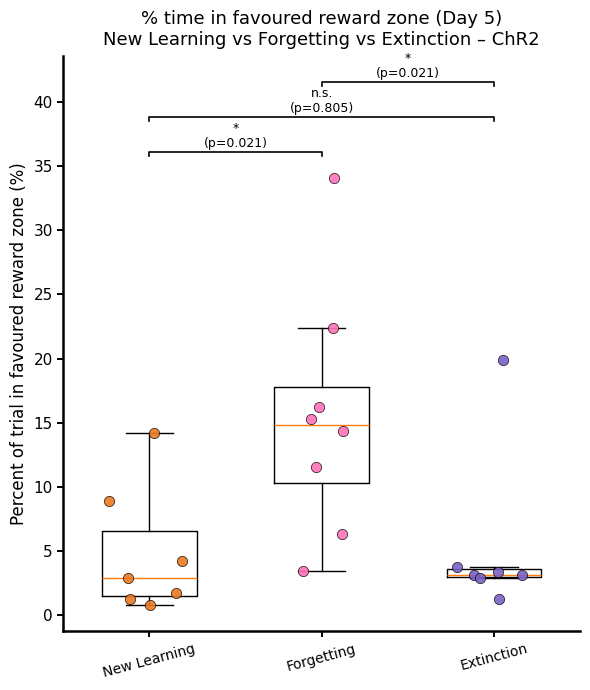

In [ ]:

from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for three groups (all ChR2, Day 5, % time)
#    - New Learning: RL day 5, trigger_id = 3 (previously favoured)
#    - Forgetting:   Test day 5, trigger_id = 2 (favoured)
#    - Extinction:   Test day 5, trigger_id = 2 (favoured)
#    Metric: pct_in_trigger_trig (% of trial in that zone),
#            averaged per animal for that day.
#    Source: meta_pct
# ------------------------------------------------------------

# ---- New Learning (RL day 5, trig=3) ----
rl_df_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'RL') &
    (meta_pct['trigger_id'] == 3) &
    (meta_pct['trial_type_day'] == 5) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

rl_per_sub_pct = (
    rl_df_pct.groupby('sub')['pct_in_trigger_trig']
             .mean()
             .astype(float)
)
vals_rl_pct = rl_per_sub_pct.values   # percent


# ---- Forgetting (Test day 5, T, trig=2) ----
forg_df_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'T') &
    (meta_pct['test_type'] == 'forgetting') &
    (meta_pct['trigger_id'] == 2) &
    (meta_pct['trial_type_day'] == 5) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

forg_per_sub_pct = (
    forg_df_pct.groupby('sub')['pct_in_trigger_trig']
               .mean()
               .astype(float)
)
vals_forg_pct = forg_per_sub_pct.values   # percent


# ---- Extinction (Test day 5, T, trig=2) ----
ext_df_pct = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'T') &
    (meta_pct['test_type'] == 'extinction') &
    (meta_pct['trigger_id'] == 2) &
    (meta_pct['trial_type_day'] == 5) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

ext_per_sub_pct = (
    ext_df_pct.groupby('sub')['pct_in_trigger_trig']
              .mean()
              .astype(float)
)
vals_ext_pct = ext_per_sub_pct.values   # percent

print("N per group (Day 5, % time):")
print("  New Learning (RL, trig3):", len(vals_rl_pct))
print("  Forgetting (T, trig2):   ", len(vals_forg_pct))
print("  Extinction (T, trig2):   ", len(vals_ext_pct))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl_pct,   vals_forg_pct,   vals_ext_pct]
positions = np.arange(len(groups))

colors = {
    "New Learning": "#EC7920",   # orange (same as line plot)
    "Forgetting":   "#FF72B8",   # pink
    "Extinction":   "#7b62c5ff"  # purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 7))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",   0, 1, vals_rl_pct,   vals_forg_pct),
    ("RL vs Ext",    0, 2, vals_rl_pct,   vals_ext_pct),
    ("Forg vs Ext",  1, 2, vals_forg_pct, vals_ext_pct),
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    if np.isnan(p):
        continue
    stars = p_to_stars(p)

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max,
         current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Percent of trial in favoured reward zone (%)', fontsize=12)
ax.set_xlabel('')
ax.set_title(
    '% time in favoured reward zone (Day 5)\n'
    'New Learning vs Forgetting vs Extinction – ChR2',
    fontsize=13,
    pad=8
)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()